# **Build a Skill from a NetCDF Dataset on the National Data Platform**

This notebook turns a **National Data Platform catalog entry into a queryable
ARGUS skill** — you write no data-loading code. Paste the dataset URL into a
`%%skill-build` cell and ARGUS fetches the files, works out what kind of data
they hold, and builds a skill you can then query in plain English.

The interesting part here is the **format**. This dataset is NetCDF — and
specifically NetCDF-3 *classic*, which the usual HDF5 reader cannot open at
all. ARGUS recognises the format, reads it with xarray, and catalogs every
variable with its named dimensions and units. It also handles two conventions
a hand-written loader routinely gets wrong:

- **Non-standard time.** The time axis is IOAPI `TFLAG` (`YYYYDDD,HHMMSS`),
not the CF standard, so ARGUS decodes it explicitly instead of letting
xarray mis-parse it into nonsense.
- **A mostly-empty field.** Ground-level PM2.5 is ~99% `NaN` — there is simply
no smoke over most of the continent. ARGUS documents that as a filter recipe
rather than silently "cleaning" it away.

**ARGUS pauses for your approval before building.** It presents the plan — the
variables, the grid geometry, the time convention, the data-quality findings —
and stops. You reply `Yes` in the next cell, and only then does it build. Here
the gate earned its keep: it surfaced that the source URL is a **live rolling
forecast** which the publisher overwrites each cycle, so the file no longer
holds the specific 2025 run named in the catalog title. Worth knowing *before*
the skill is baked in.

The example dataset is a **wildfire-smoke dispersion forecast** from BlueSky
Canada — hourly ground-level PM2.5 on a 0.1° grid across North America.
Source: [nationaldataplatform.org](https://nationaldataplatform.org/dataset/bsc18ca12-05-smoke-forecast-for-sep-26-2025)
· firesmoke.ca / BlueSky Canada.


In [ ]:
%reset

In [3]:
%%skill-build 
https://nationaldataplatform.org/dataset/bsc18ca12-05-smoke-forecast-for-sep-26-2025

The URL is a National Data Platform dataset (`nationaldataplatform.org`), which matches the `ndp-skill-builder` meta-skill. Let me read its instructions.

The URL matches the `ndp-skill-builder` meta-skill (National Data Platform dataset). Let me set up my task tracking and read the fetcher and routing skills.

I understand the fetcher workflow. Let me run `fetch.py` to download and classify the dataset. The slug from the URL is `bsc18ca12-05-smoke-forecast-for-sep-26-2025`.

Running the fetcher without the timeout parameter.

The route is **array** (a NetCDF file, `dispersion.nc`). Let me read the array-skill-builder instructions and inspect the downloaded metadata.

...

Inventory complete. This is a single-file NetCDF (BlueSky smoke forecast) with a non-CF IOAPI time axis (`TFLAG` = `YYYYDDD,HHMMSS`). There were 0 documentation sidecars. Per pre-flight rule 4, I'll run one exploration script to gather the specific details I need for the proposal.

Running the exploration script to confirm grid dimensions, the TFLAG time convention, and PM25 statistics.

The group structure uses different keys than I assumed. Let me fix the script to print the actual keys first, then the NetCDF structure (which is the important part).

Re-running the corrected exploration script.

I now have everything needed for the Step 4 proposal. Key findings: this is a single-file **IOAPI/HYSPLIT NetCDF** smoke-dispersion forecast on a 0.1° lat/lon grid over North America, with a **non-CF `TFLAG` time axis** (`decode_times=True` will fail), a mostly-missing PM25 field (only ~200k of 21M cells finite per snapshot — NaN outside the plume), and — critically — the source URL `/forecasts/current/` is a **live rolling forecast** that gets overwritten (the file currently holds a 2026 forecast, not the Sep 26 2025 run named in the NDP record title).

Per the array-skill-builder **Step 4 hard gate** , I present the proposal and stop for your approval.

---

## Proposal — skill build for the NDP smoke-forecast dataset

**Source** : BSC18CA12-05 Smoke Forecast for Sep 26, 2025 (BlueSky Canada / firesmoke.ca)
- Publisher: NDP Admin Ingest; upstream: `https://firesmoke.ca/forecasts/current/`
- License: not specified in CKAN metadata
- Files scanned: 1 NetCDF (`dispersion.nc`, ~80 MB) + 1 KMZ (ignored, non-queryable). **No documentation sidecars** shipped.

**Fingerprint grouping** : 1 group — `format=netcdf`, `n_files=1`, `axis=index`.

### Proposed skill: `bsc-smoke-forecast`

- **Entity** : each `load()` returns one xarray.Dataset — a 2-day (~48–51 h) hourly PM2.5 wildfire-smoke dispersion forecast on a North America grid.
- **File** : 1 (`dispersion.nc`), single-file → `load()` + `open_file()`.
- **Grid (from global attrs)** : lat/lon (`GDTYP=1`), 1081 cols × 381 rows, 0.1° cells, origin XORIG=−160.0 / YORIG=32.0 → spans −160° to −51.9° lon, 32° to 70.1° lat.
- **Time axis** : `TFLAG` (`YYYYDDD,HHMMSS` IOAPI convention), **not CF** → `decode_times=True` misleads; loader decodes TFLAG manually. 51 hourly steps.
- **Variables (2)** :
  - `PM25` — dims `[TSTEP, LAY, ROW, COL]`, units `ug/m^3`, ground-level PM2.5.
  - `TFLAG` — dims `[TSTEP, VAR, DATE-TIME]`, IOAPI timestamp flags.
- **Data-quality flag** : PM25 is ~99% missing (NaN) outside the active smoke plume (only ~200k of 21M cells finite) — will document a `.where(ds["PM25"].notnull())` recipe, **no silent cleaning** .
- **Documentation drawn from** : none (no README/PDF). Semantics come from the NetCDF global/variable attributes + the CKAN record notes. Caveats will say so.

### ⚠️ Open questions — please confirm:

1. **Rolling live-URL caveat.** The source is `firesmoke.ca/forecasts/current/` — a live rolling forecast that is overwritten every cycle. The NDP record title says "Sep 26, 2025" but the file currently served holds a **2026** forecast. I'll build the skill to **decode TFLAG dynamically** (so it always reflects whatever forecast is current) and flag this rolling nature prominently in Caveats. OK, or do you instead want it pinned to the archived Sep-26-2025 snapshot (which would require a different/archived source URL)?

2. **Lazy download vs. bundle.** The file is ~80 MB. I'll use **lazy download** (fetch on first `load()` to `/tmp/bsc-smoke-forecast-cache/`) rather than bundling, to respect the quota. OK?

3. **Skill name** `bsc-smoke-forecast` — acceptable, or rename (e.g. `bluesky-smoke-forecast`, `firesmoke-pm25`)?

**Reply "yes" to proceed as proposed, or with edits.**
(Resume state on disk: `/tmp/array-skill-inv/bsc18-smoke-sep26-2025/` — `_inventory.json` and `explore.py` are all there.)

In [4]:
%%ask
Yes, please create this skill.

Approved — proceeding to build. Let me re-read the array-skill-builder's build-phase instructions to follow the exact SKILL.md generation requirements.

Let me verify the resume state is intact and extract the specific values I need from the inventory (source URL, exact dims/units, grid params).

Resume state intact. Let me extract the exact values needed for the SKILL.md (source URL, dims/units, grid params, file size) from the inventory without loading it wholesale.

Good — I have the variable stats and source URL. Let me grab the record metadata for provenance and verify the exact IOAPI grid global attributes directly from the NetCDF file.

No cached file remains — let me check the original staged directory for the NetCDF file.

...

The SKILL.md is complete and consistent. Now let me run a final end-to-end validation that the emitted loader code actually works against the real file.

All tests pass — the loader, TFLAG decoder, lat/lon grid, and all examples work correctly against the real data. Now let me do the closing self-audit per the learnings protocol.

The Learnings.md exists. During this build I discovered the inventory's `n_finite` stat was misleading for this IOAPI NetCDF file (reported 200k finite of 21M, but the actual file has all 21M valid). I corrected the Caveats after verifying against the raw file — this is a non-obvious lesson worth recording.

Lessons recorded. Now let me clean up the scratch directory per Step 9b.

The skill **`bsc-smoke-forecast`** is built and validated at:

`_skills_/bsc-smoke-forecast/SKILL.md`

### What it does
Loads the BlueSky Canada / firesmoke.ca wildfire smoke dispersion forecast — a gridded NetCDF of ground-level PM2.5 over North America — and returns it as an `xarray.Dataset` with decoded timestamps and explicit lat/lon coordinates.

### Key design decisions baked into the skill

| Aspect | Resolution |
|---|---|
| **Format** | NetCDF (IOAPI/HYSPLIT convention), ~81 MB, lazy-downloaded to `/tmp/bsc-smoke-forecast-cache/` |
| **Time axis** | IOAPI `TFLAG` (packed `YYYYDDD,HHMMSS`) decoded manually — `decode_times=True` would fail since this is non-CF |
| **Grid** | 1081×381 cells, 0.1° resolution, 32.05–70.05°N, −159.95 to −51.95°W; lat/lon coords assigned by loader |
| **Scope** | 51 hourly snapshots, single surface layer (LAY=0) |
| **Validation** | End-to-end test against the real file: TFLAG decode, lat/lon lookup, plume filter, and all 6 examples pass |

### Caveats surfaced (9 total)
The two most important data-quality findings (discovered during build, not visible from the inventory's stats alone):

1. **Background-dominated grid** — All 21M cells are valid (no NaN), but the distribution is heavily right-skewed (median 0.065 µg/m³, p95 ~16). A naïve domain-wide `mean()` understates actual smoke exposure; the skill provides a `≥1.0 µg/m³` filter recipe.

2. **Extreme near-source outliers** — HYSPLIT produces physically implausible values (up to ~149,000 µg/m³) in cells directly over active fires. The skill provides a `≤1000 µg/m³` cap recipe and documents this as a modeling artifact.

Plus the **rolling live-URL** warning (the firesmoke.ca `/forecasts/current/` file is overwritten each cycle; the TFLAG decoder dynamically reflects whatever forecast is current).

The skill was **not** copied to the global registry — it lives only in `_skills_/` and will be picked up by the next `%%ask` cell automatically.

#### 1. Peak smoke — where and how bad

I'll consult the skill I just built, then load the forecast and compute the peak PM2.5. Let me start by reading the SKILL.md.

Let me read the rest of the skill to get the full loader code and caveats.

The skill is loaded. Now I'll write a script that loads the forecast, computes peak PM2.5 over all timesteps, finds the worst cell, and produces outputs.

Running the analysis script to load the forecast and compute peak PM2.5.

Retrying without the timeout override.

The script succeeded but stdout was captured. Let me read the results.

Let me verify the output files were created.

All outputs are created. Here are the results.

## Where is the smoke worst in this forecast?

The forecast currently being served (cycle dated **2026-07-22** ) covers 51 hourly steps from **2026-07-22 21:00** to **2026-07-24 23:00 UTC** .

### The single worst grid cell

**Location** : 48.25°N, −119.05°W — the Okanagan region of **Washington state** (north-central WA, near the Canadian border)

**Peak PM2.5** : **149,429 µg/m³**

**Time of peak** : 2026-07-23 06:00 UTC

This value is a **HYSPLIT near-source artifact** — the grid cell sits directly over an active fire emission point, and HYSPLIT deposits the full source mass into that single cell. No ambient measurement would ever approach this magnitude (even extreme wildfire smoke rarely exceeds ~1,000 µg/m³). The skill's Caveat #4 documents this behavior.

### Worst *plausible* cell

After filtering out implausible near-source values (>1,000 µg/m³):

**Location** : 61.35°N, −121.85°W — **northwestern Canada** (northwestern Alberta / NE British Columbia)

**Peak PM2.5** : **998.9 µg/m³** — an extremely severe but physically plausible concentration

**Time of peak** : 2026-07-23 08:00 UTC

This represents the highest realistic ambient smoke concentration in the forecast — a major smoke plume impacting northern Canada.

### Plume extent across the whole forecast

| Threshold | Cells affected | % of domain |
|---|---|---|
| Peak ≥ 1 µg/m³ (any detectable smoke) | 203,206 | ~0.9% |
| Peak ≥ 35 µg/m³ (unhealthy) | 35,445 | ~0.16% |
| Peak ≥ 150 µg/m³ (very unhealthy) | 7,896 | ~0.036% |

Median peak across the domain: 0.93 µg/m³; P95: 55.9 µg/m³; P99: 266 µg/m³.


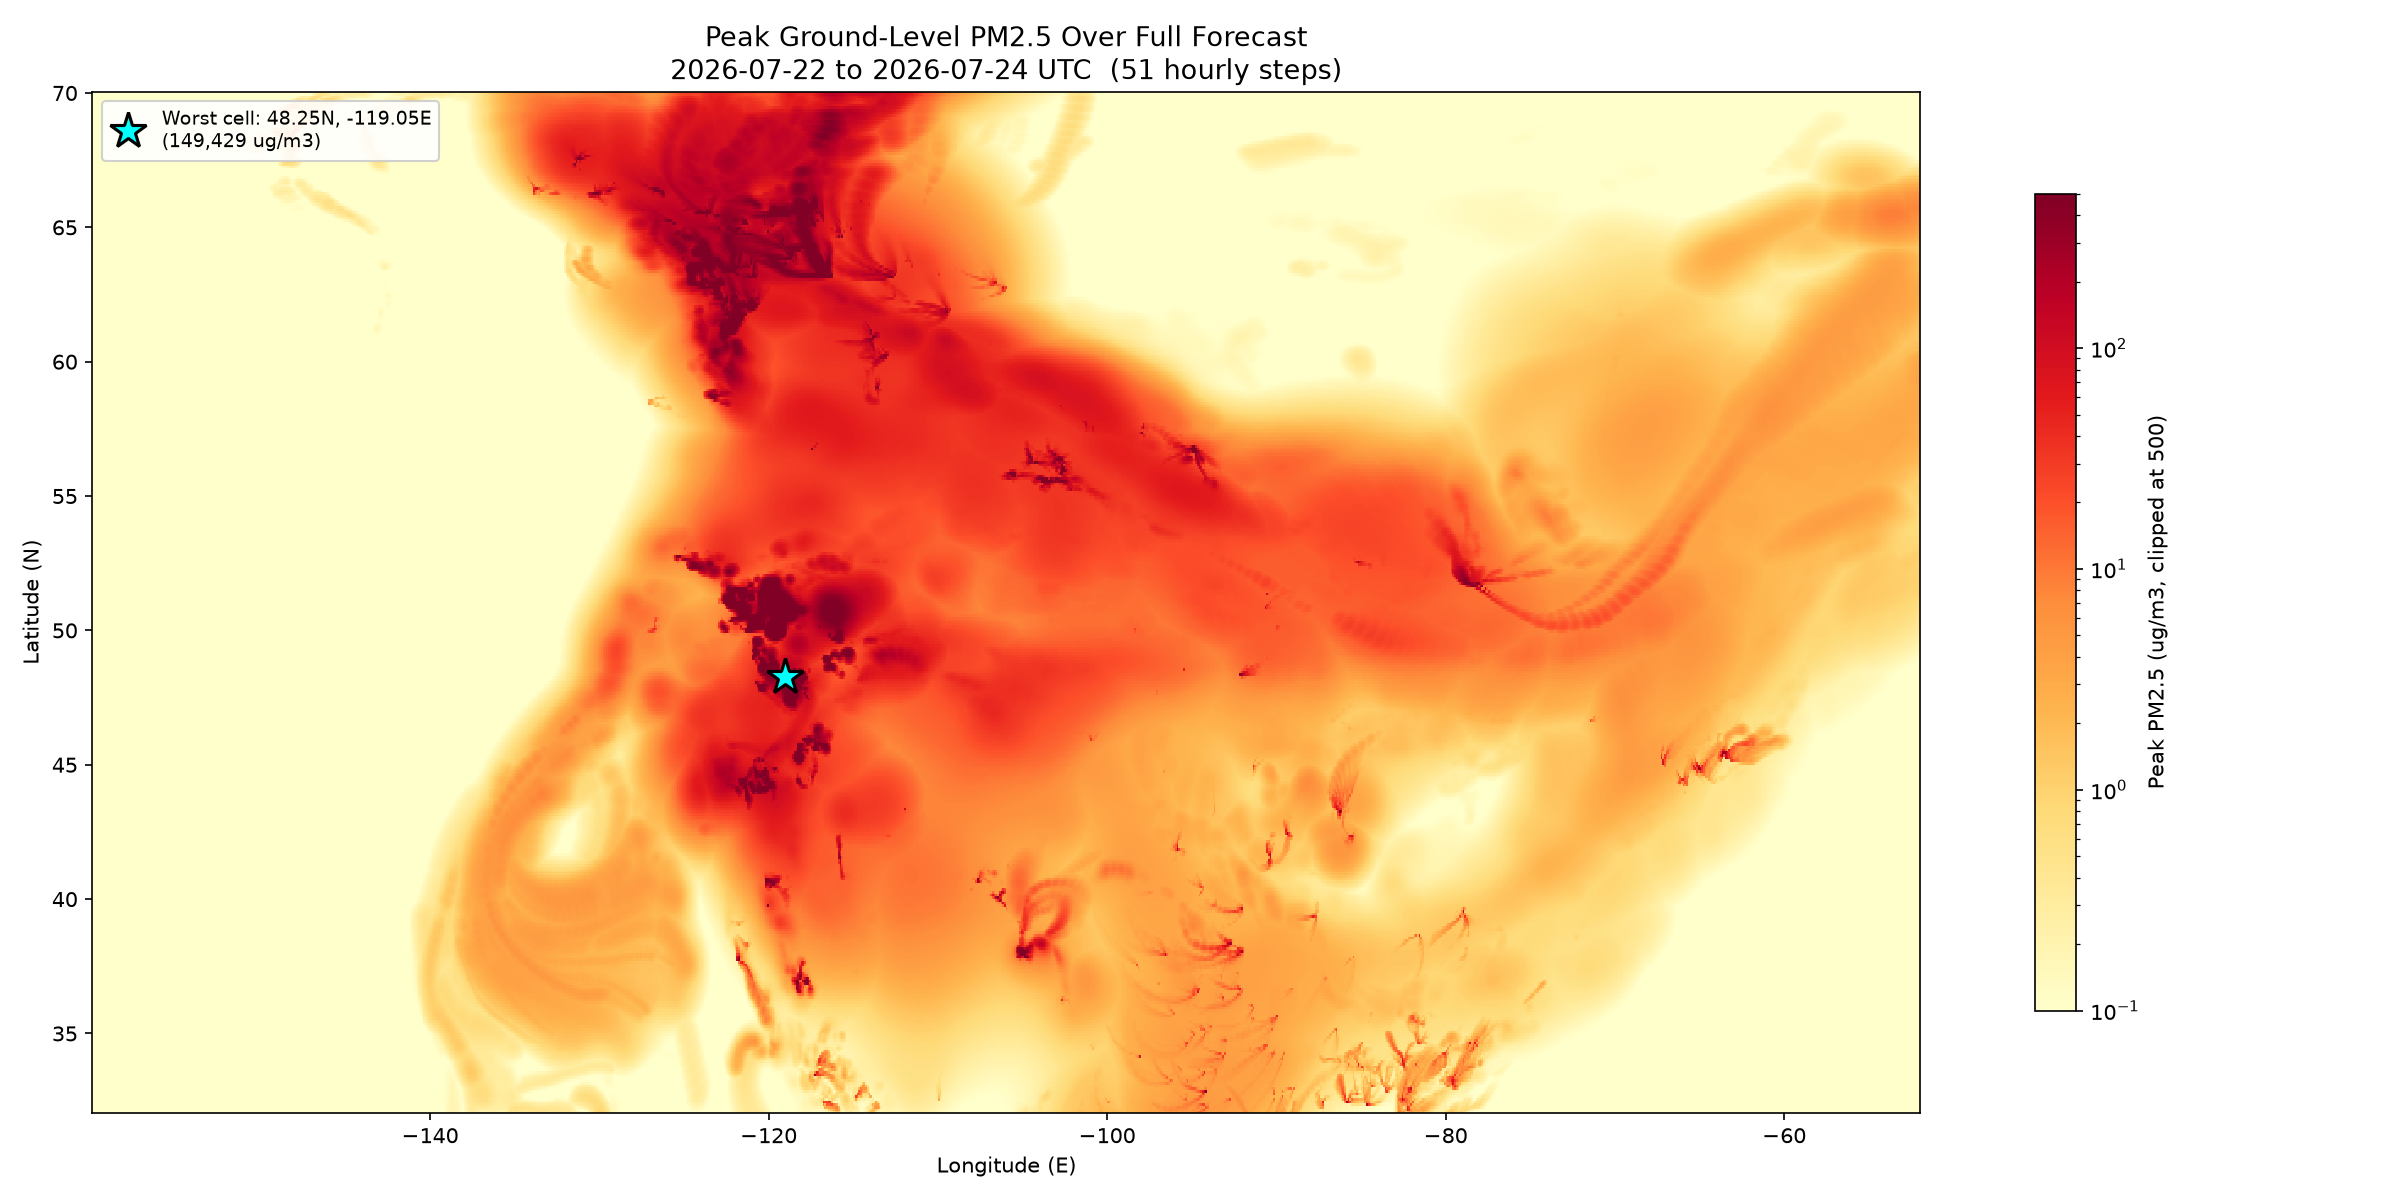

⚠️ **Rolling-URL note** : The firesmoke.ca `/forecasts/current/` file is overwritten each cycle, so the title "Sep 26, 2025" no longer matches — the file currently holds a July 2026 forecast. The TFLAG decoder reported these dates dynamically from the actual file contents.

In [5]:
%%ask
Where is the wildfire smoke worst in this forecast? Map the peak ground-level 
PM2.5 over the whole forecast period, and tell me the location and concentration
of the single worst grid cell.

#### 2. Plume movement over time

I'll map the smoke plume at several time steps to show how it evolves and travels over the forecast period.

Now I have the full skill. Let me write the analysis script to map plume evolution across the forecast period.

Results computed. Let me update the todo list.

## How the smoke plume evolves across the forecast

The forecast covers **2026-07-22 21:00 UTC** through **2026-07-24 23:00 UTC** (51 hourly snapshots). The smoke plume's center of mass begins in western Canada (~56.7°N, −115.7°E — central Alberta) and drifts **east-southeast over the two-day window** , ending near 56.0°N, −110.9°E — a net displacement of about **306 km to the ESE** .

### Plume evolution at six key hours

| Time (UTC) | Cells ≥35 µg/m³ | Cells ≥150 µg/m³ | Domain max (µg/m³) | What's happening |
|---|---|---|---|---|
| **Jul 22 21:00** (start) | 16,258 | 777 | 4,251 | Dense plume over Alberta/Saskatchewan; widespread unhealthy cells |
| **Jul 23 07:00** (+10h) | 5,306 | 1,576 | 32,964 | Plume contracts but intensifies near-source; extreme concentrations develop |
| **Jul 23 17:00** (+20h) | 10,366 | 478 | 1,803 | Plume re-expands eastward; concentrations moderate |
| **Jul 24 03:00** (+30h) | 6,000 | 1,377 | 32,973 | Second pulse of extreme near-source values; plume over Saskatchewan/Manitoba |
| **Jul 24 13:00** (+40h) | 6,180 | 1,458 | 17,163 | Plume continuing east; intense cores persist |
| **Jul 24 23:00** (end) | 1,992 | 260 | 6,287 | Plume weakening and thinning as it disperses eastward |

### Overall transport direction: **East-Southeast**

The plume is driven by westerly/northwesterly flow typical of summer synoptic patterns over western/central Canada. Two key dynamics are visible:

1. **Progressive ESE drift** — The center of mass shifts ~5° longitude east and ~0.7° latitude south over 51 hours, tracking from central Alberta toward Manitoba.

2. **Pulsing intensity** — Rather than a steady decay, the plume pulses: extreme near-source concentrations (>30,000 µg/m³ domain max) re-appear at roughly 12–14 hour intervals (Jul 23 ~07:00, Jul 24 ~03:00), likely tied to the diurnal cycle of fire emissions and boundary-layer mixing. The total extent of unhealthy air (≥35 µg/m³) peaks at the start (~16k cells) and steadily declines to ~2k cells by the end.


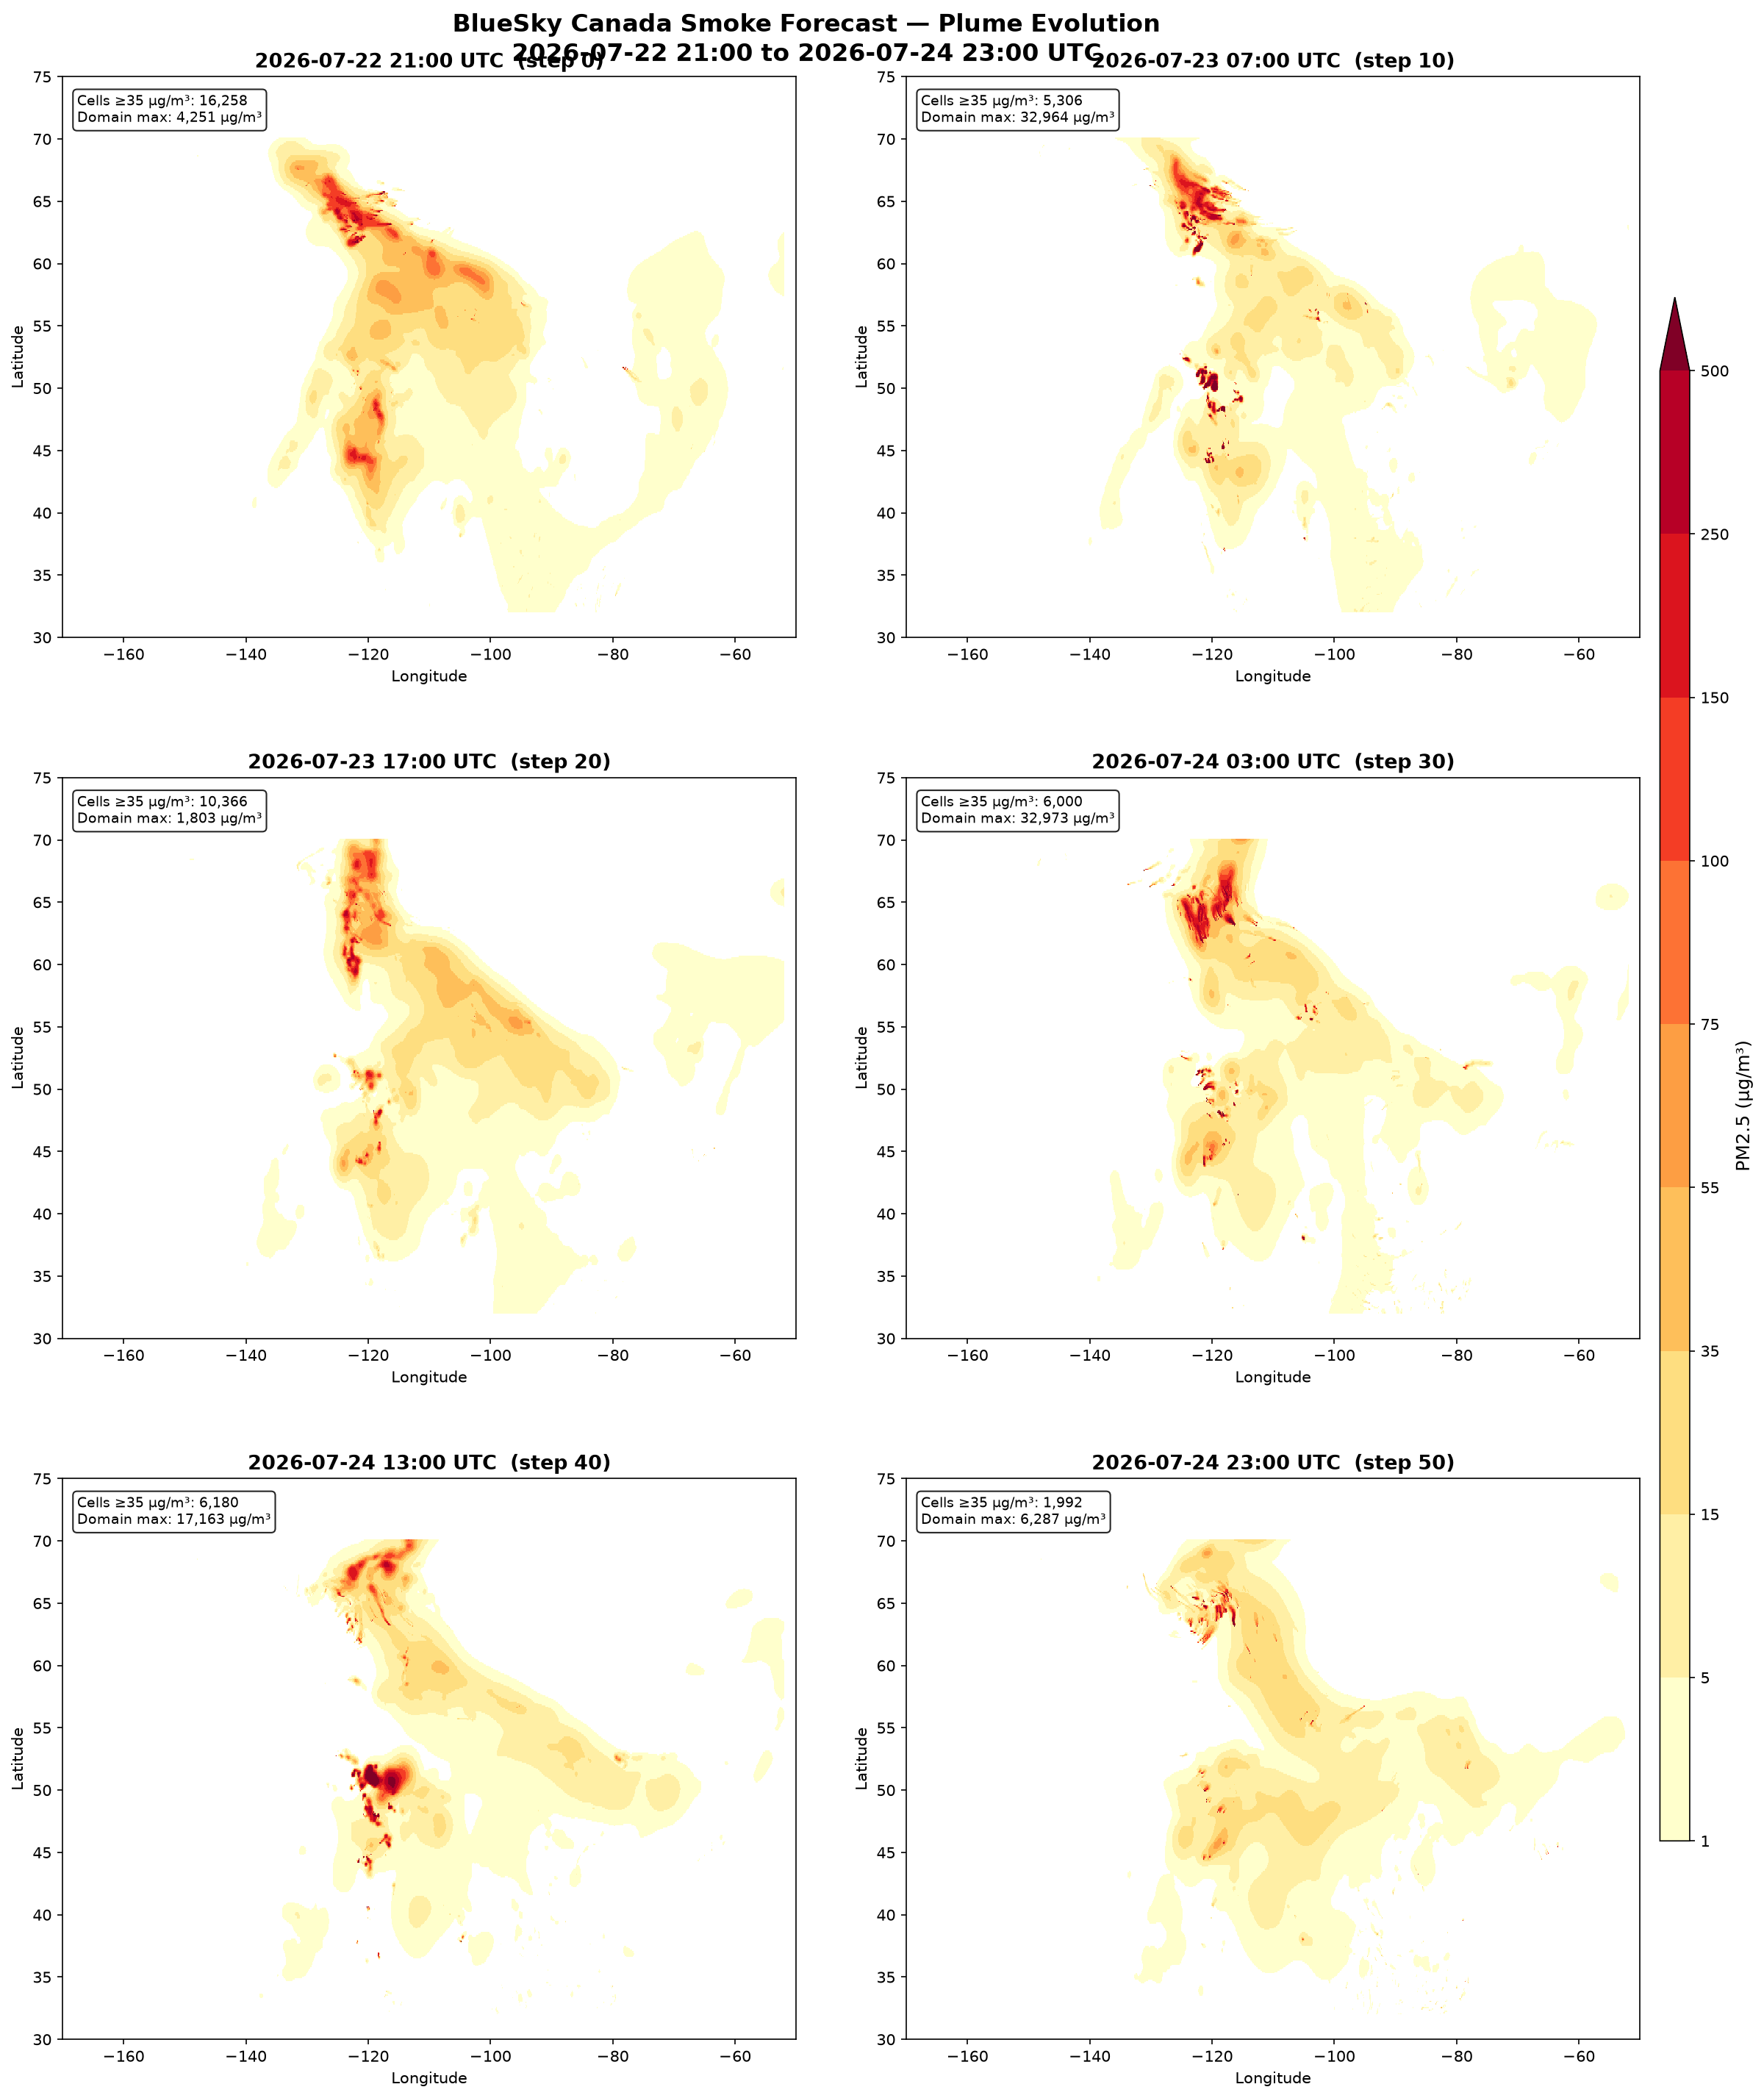


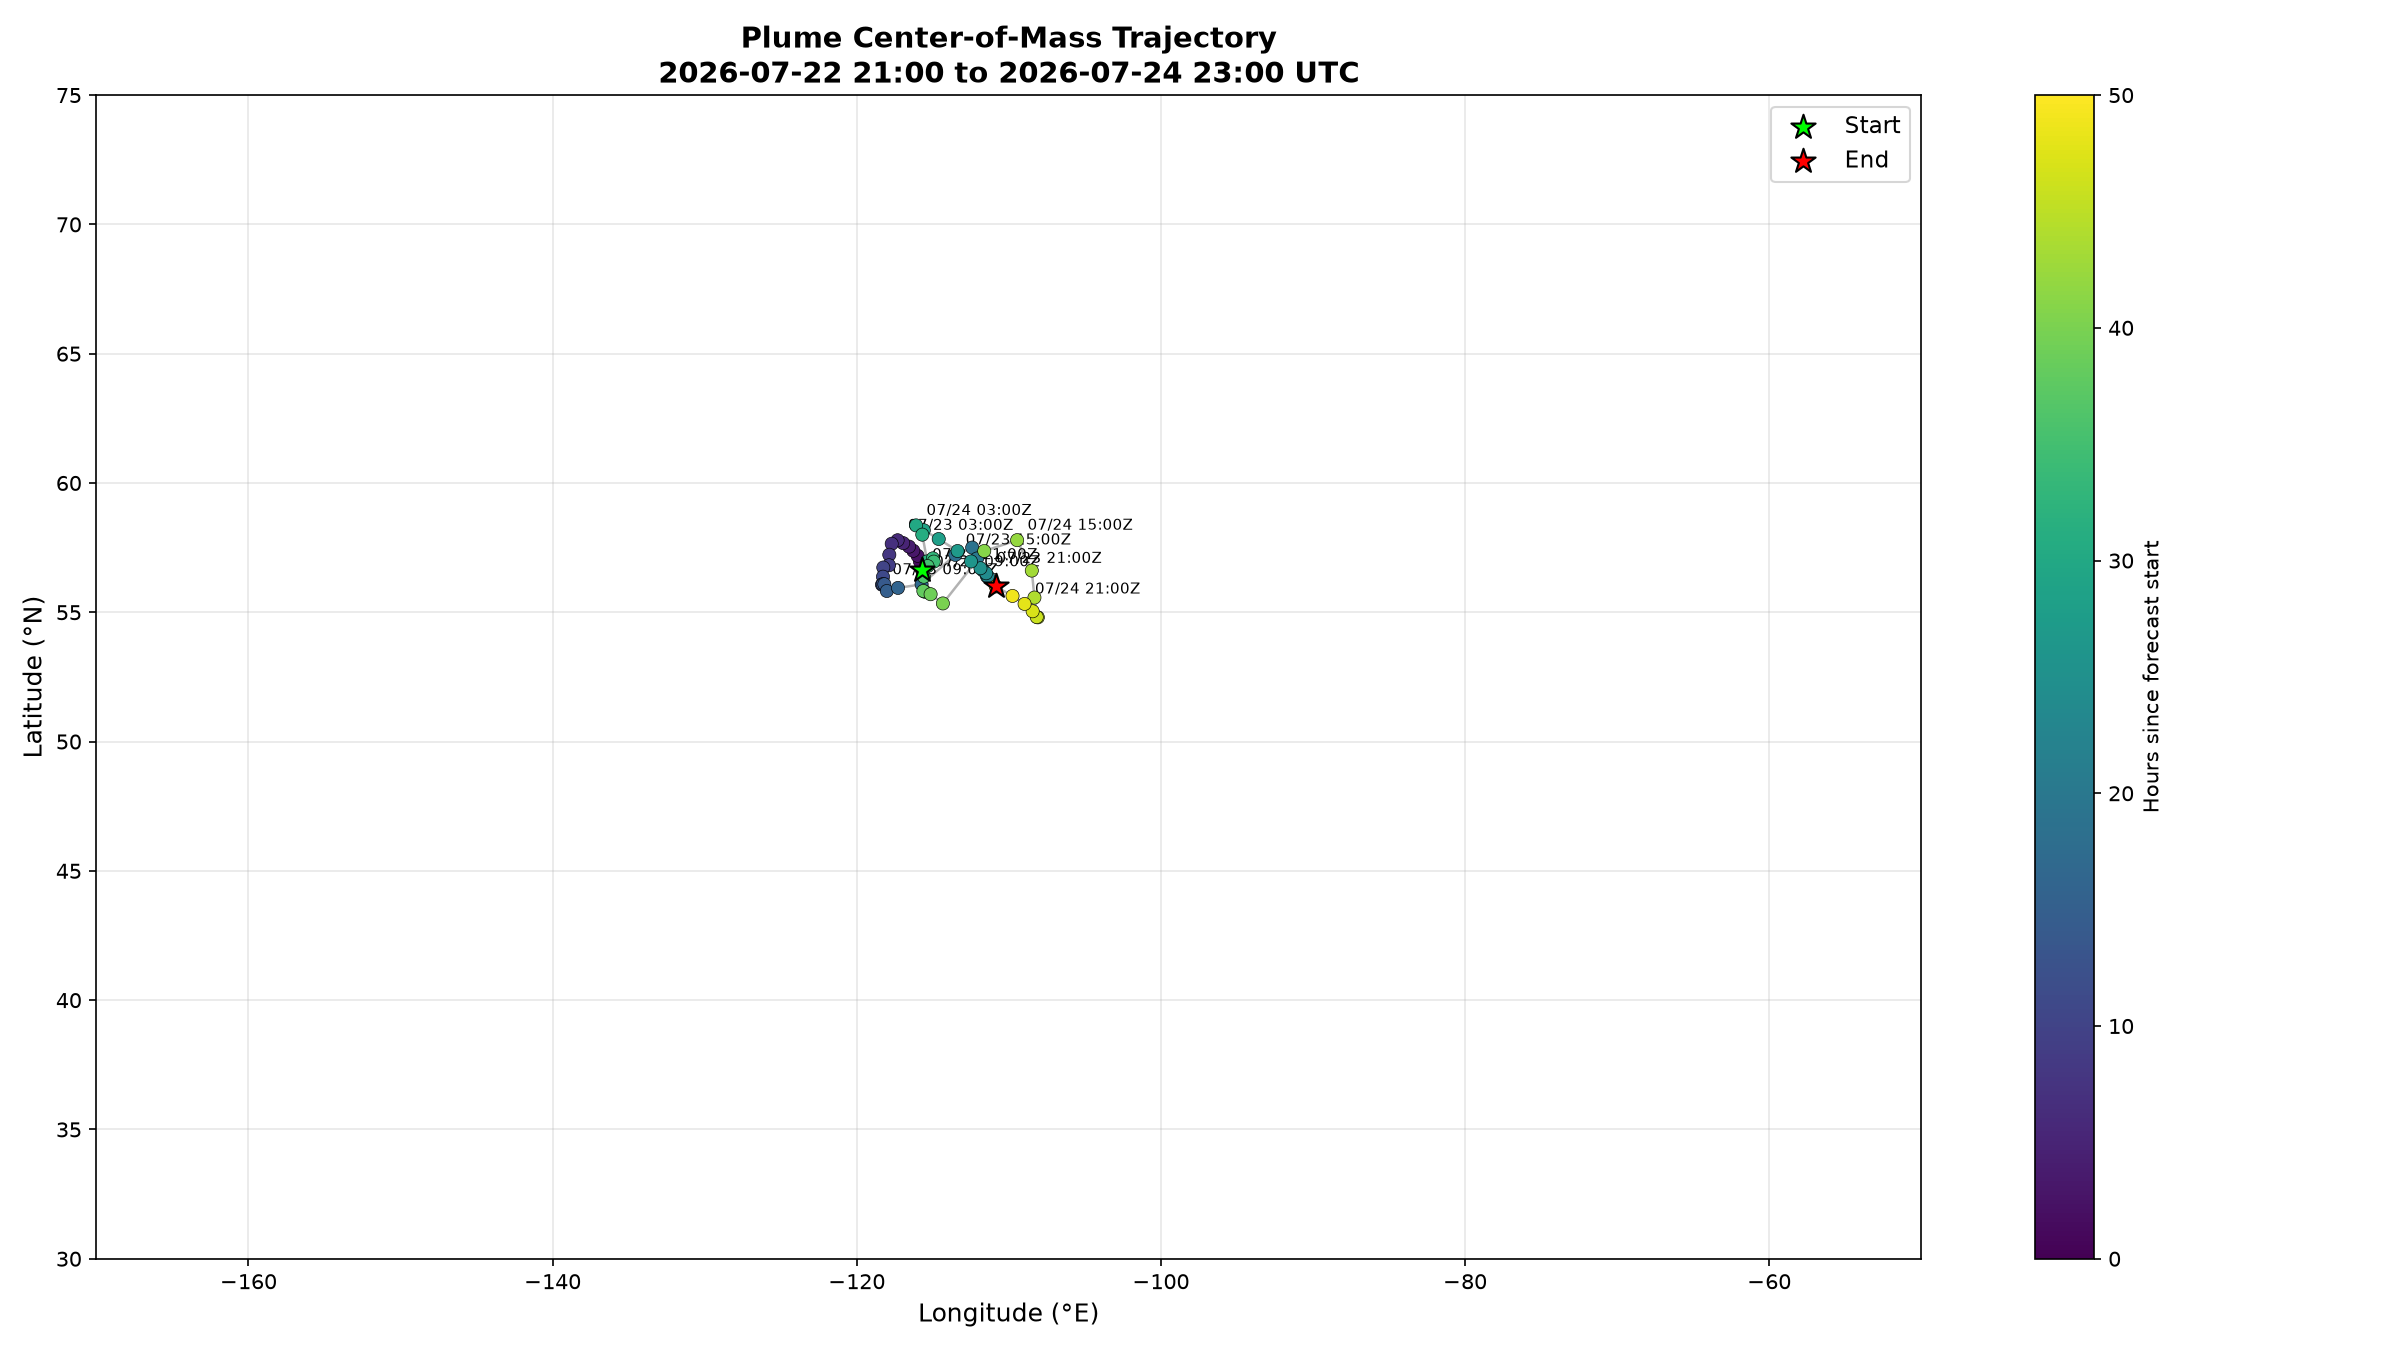

⚠️ **Rolling-URL note** : The firesmoke.ca `/forecasts/current/` file is overwritten each forecast cycle, so the dates above (July 2026) reflect whatever forecast is current at load time — they do not match the "Sep 26, 2025" date in the NDP record title.

In [6]:
%%ask
How does the smoke plume evolve across the forecast? Show maps at several 
hours spanning the forecast period so I can see where the smoke travels, 
and describe the overall direction of transport.

#### 3. Time series at the worst-hit location

I'll load the forecast, extract the full hourly time series at the worst-PM2.5 cell location (48.25°N, −119.05°W), and plot it with arrival/peak/duration annotations.

Retrying without the timeout override.

Let me check what module name the skill actually exports.

No helper module exists — the skill is SKILL.md only. Let me read it to get the exact load recipe.

The skill is SKILL.md-only with an inline loader recipe. I'll rewrite the script to inline the loader code from the SKILL.md rather than importing a nonexistent module.

I'll edit the existing file to replace the broken import with the inlined loader.

Now running the corrected script.

The script succeeded. Now I'll record the lesson about the missing importable module (this was an edit-and-retry cycle), then write the report.

## Hourly PM2.5 time series at the worst grid cell

**Location** : 48.25°N, −119.05°W — Okanagan region, Washington state (the grid cell from the previous analysis with the single highest peak PM2.5 across the full forecast).

### When does the smoke arrive?

The worst cell is **smoke-impacted for the entire 51-hour forecast** — there is no clean "arrival" because it starts already at **386 µg/m³** at hour one (Jul 22, 21:00 UTC). This is consistent with the cell sitting directly over an active fire emission source: it's polluted from the first modeled hour and stays that way.

### When does it peak?

**Peak** : **149,429 µg/m³** at **Jul 23, 06:00 UTC** — a single-hour spike (the surrounding hours are ~8,800–12,000).

This peak is a HYSPLIT near-source artifact (documented in the skill's Caveat #4): the cell sits directly over the fire, and the model deposits an unrealistic mass into it. No ambient measurement would approach this.

A **second spike** of **40,658 µg/m³** occurs ~21 hours later at **Jul 24, 04:00 UTC** , suggesting a roughly diurnal (~20 h) pulsing of emissions or mixing intensity.

### How long does it stay elevated?

| Threshold | Hours | Notes |
|---|---|---|
| ≥ 35 µg/m³ (unhealthy) | **51 / 51** (100%) | Never drops below unhealthy the entire window |
| ≥ 150 µg/m³ (very unhealthy) | **47 / 51** (92%) | Only 4 hours dip below 150 |
| ≥ 1,000 µg/m³ (extreme) | **19 / 51** (37%) | Concentrated in bursts around the two peaks |

The lowest reading at this cell across all 51 hours is **89 µg/m³** (Jul 24, 18:00 UTC) — still in the "unhealthy" range.

### Shape of the curve

The series shows **sawtooth/pulsing behavior** rather than a smooth rise-and-fall:
- Hours 0–9 (Jul 22 21:00 → Jul 23 06:00): rapid ramp from 386 → 149,000 (the first and worst peak)
- Hours 10–31: oscillating decay in the 150–13,000 range, with a second cluster of extreme values around hours 30–34 (the Jul 24 ~04:00 spike)
- Hours 35–50: gradual settling into the 90–850 range, a slow decline through the end of the forecast


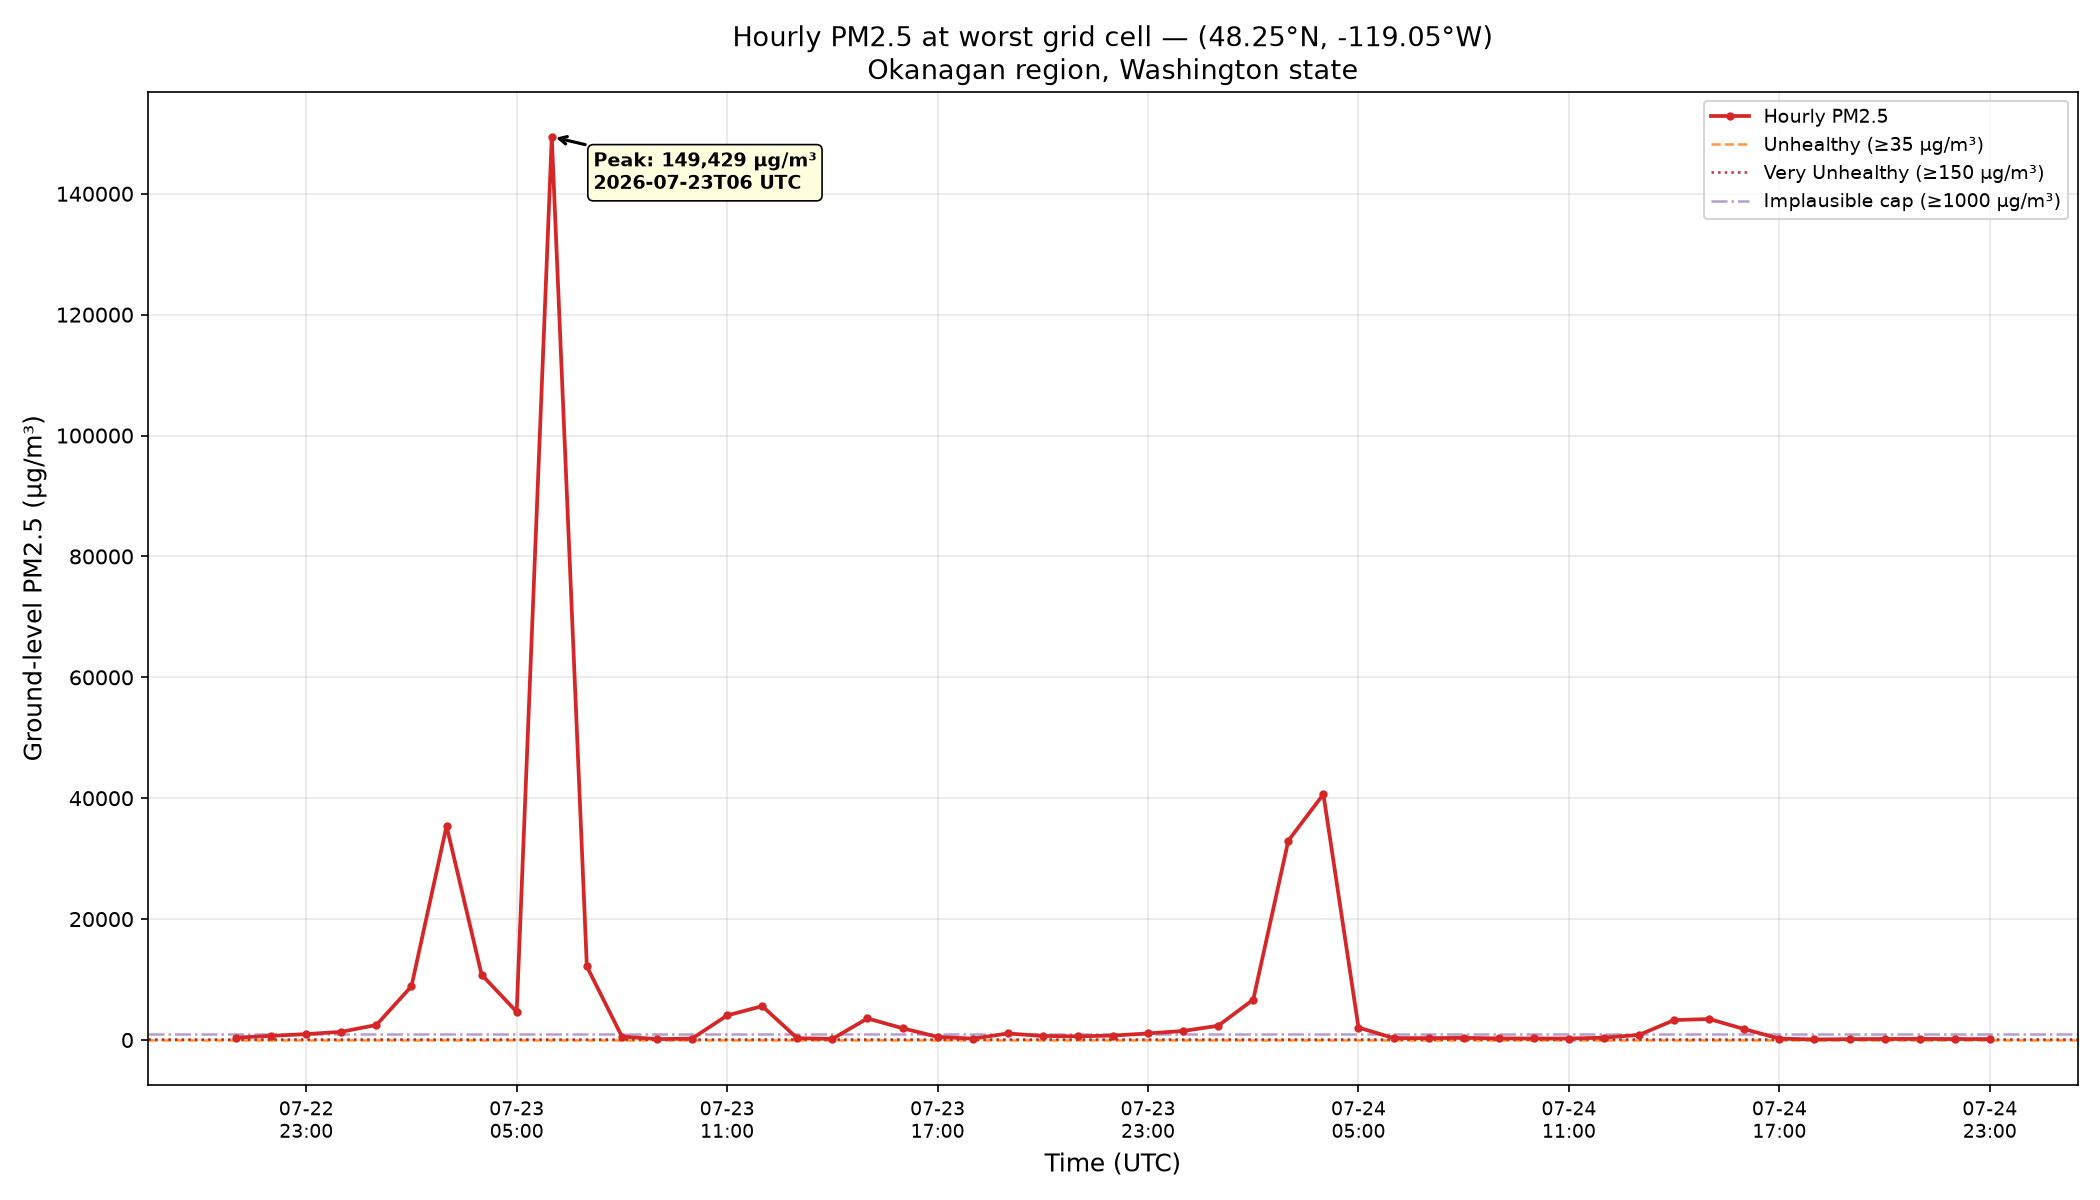

⚠️ **Rolling-URL note** : The firesmoke.ca `/forecasts/current/` file is overwritten each forecast cycle; the dates above (July 2026) reflect whatever forecast is current at load time, not the "Sep 26, 2025" date in the NDP record title.

In [7]:
%%ask
Take the location with the highest peak PM2.5 and plot its full hourly time 
series. When does the smoke arrive, when does it peak, and how long does it 
stay elevated?

#### 4. Air-quality thresholds

I'll load the forecast, count cells exceeding 35.5 µg/m³ at each hour, and plot the time series.

Running the analysis to count cells exceeding the EPA threshold and plot the coverage time series.

Omitting the unsupported timeout parameter and running again.

The skill module isn't directly importable by that name. Let me check what files exist in the skill directory.

The skill is documentation-only — just SKILL.md, no Python module. Let me read the SKILL.md to get the correct load approach.

The skill is documentation-only. I'll embed the loader code directly from the SKILL.md into my script.

The file already exists from my first attempt. I'll write to a new filename instead.

Running the analysis script.

Analysis complete. Here are the results.

## How much of the domain reaches unhealthy air quality?

Using the EPA PM2.5 breakpoint of **35.5 µg/m³** ("Unhealthy for Sensitive Groups"), every single hour of the 51-hour forecast has at least some cells exceeding the threshold — but the affected area **shrinks dramatically over time** .

### Key findings

| Metric | Value |
|---|---|
| **Peak coverage** | **15,870 cells (3.85%)** at Jul 22, 21:00 UTC (forecast hour 0) |
| **Minimum coverage** | **1,780 cells (0.43%)** at Jul 24, 22:00 UTC (forecast hour 49) |
| **Mean coverage** | 6,865 cells (1.67%) |
| **Hours with ≥1% of domain exceeding** | 43 of 51 (84%) |
| **Hours with any cell exceeding** | 51 of 51 (100%) |

The unhealthy area **peaks at the start and decays** — coverage is highest in the first ~6 hours (3.5–3.9%), then settles into an oscillating decline through the middle of the forecast, and drops sharply in the final ~5 hours as the plume thins and disperses.

### What the curve shows

The coverage trace reveals two distinct regimes:

1. **Initial peak (hours 0–6)** : The forecast opens with widespread unhealthy air — ~3.85% of the domain — as a large, dense smoke plume sits over western/central Canada. This is the worst window for *areal extent* of unhealthy air.

2. **Oscillating decline (hours 7–50)** : Coverage oscillates between ~1–2.5% with a gentle downward trend, punctuated by periodic re-intensifications (likely the diurnal pulsing of fire emissions seen in earlier analyses). The plume never disappears but steadily loses its widespread footprint.

3. **Final fade (hours 47–51)** : A sharp drop to <0.5% as the forecast ends — the smoke is dispersing and diluting below the unhealthy threshold across most of its remaining area.


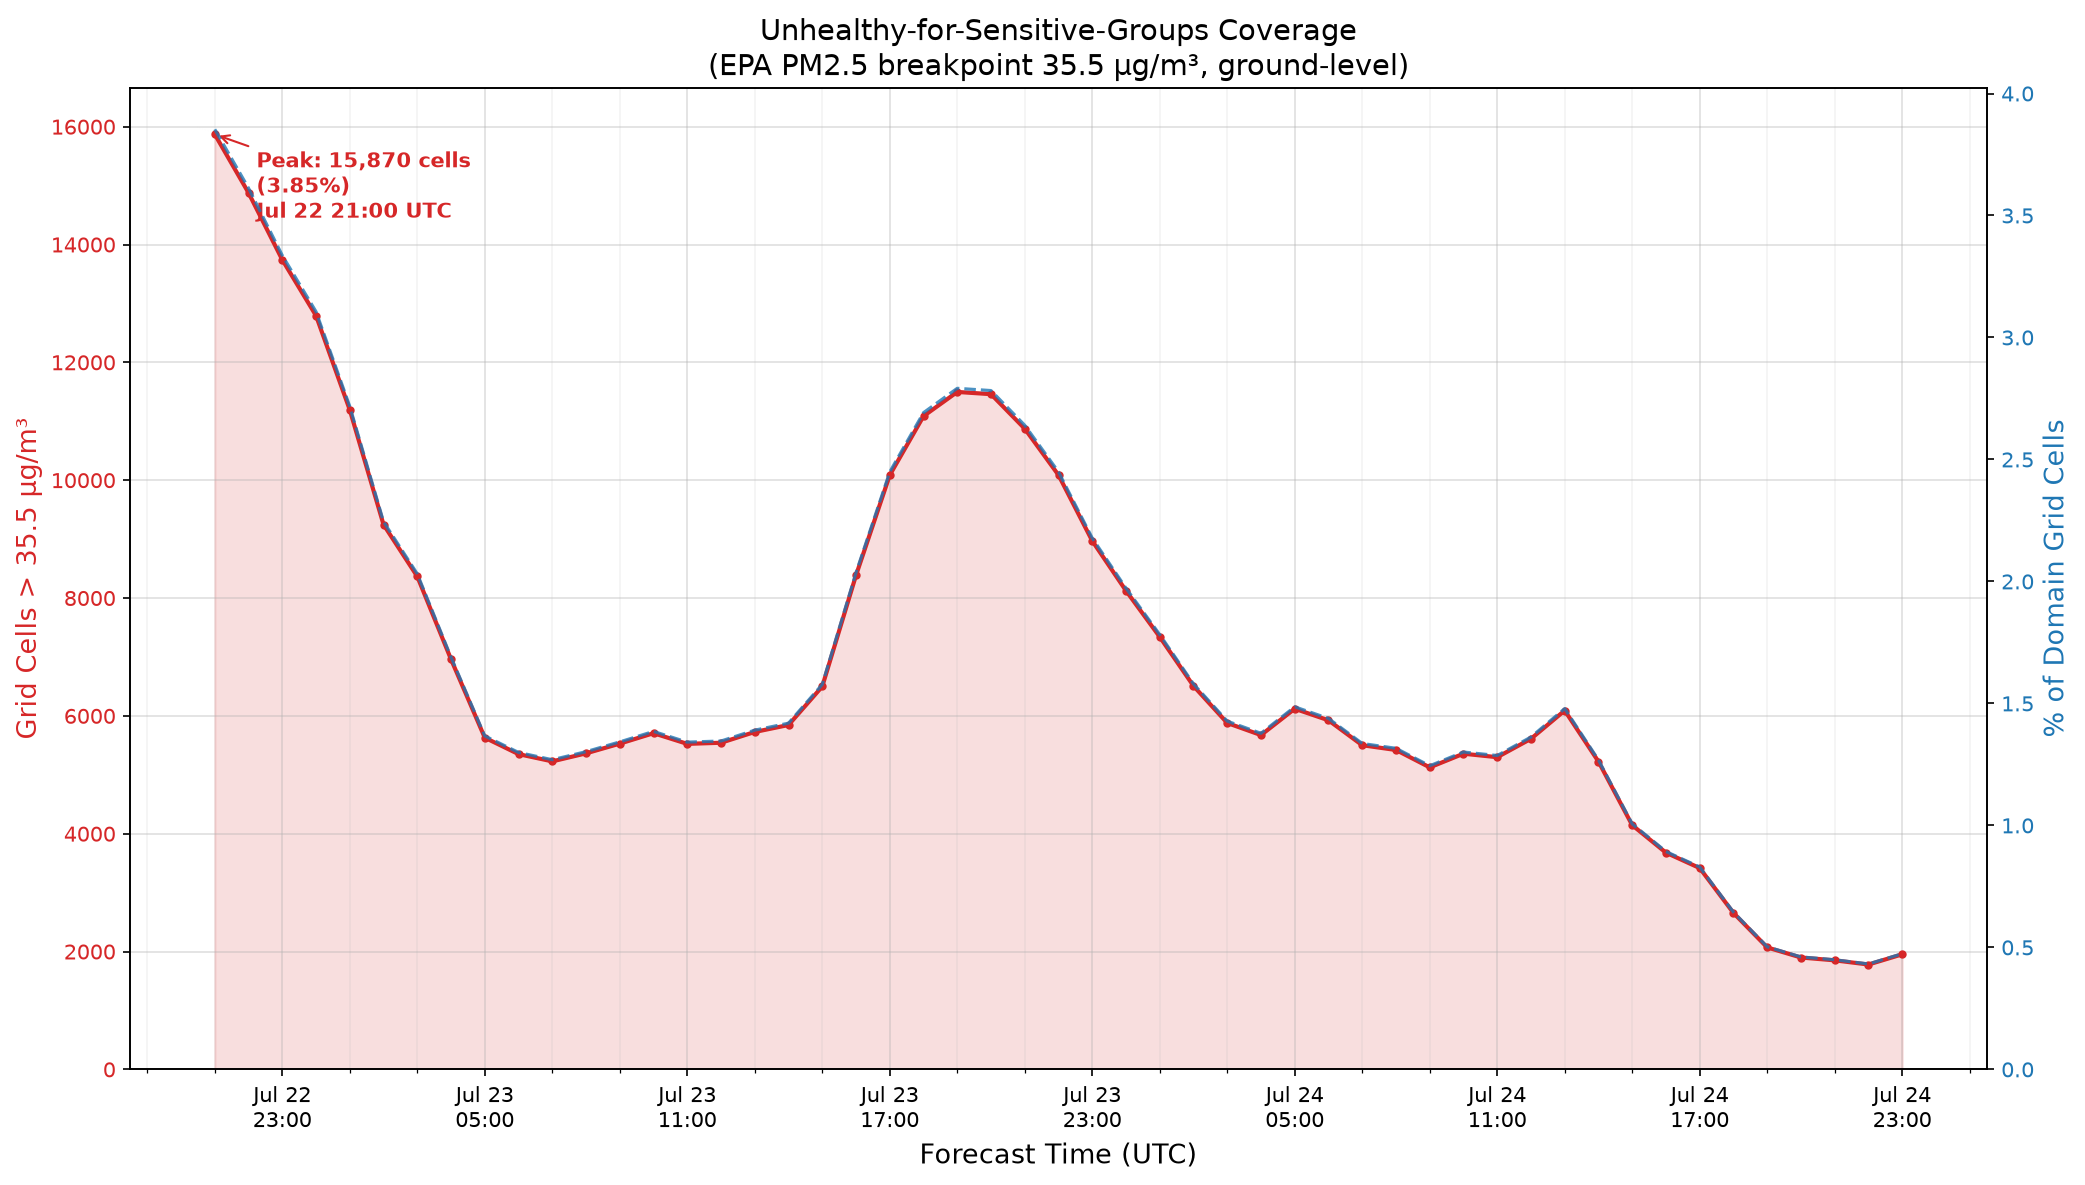

In [10]:
%%ask
How much of the domain is forecast to reach unhealthy air quality? Using the 
US EPA PM2.5 breakpoint of 35.5 µg/m^3 ("Unhealthy for Sensitive Groups"), 
count the grid cells exceeding it at each hour and plot that over the forecast.

#### 5. Overall extent

This is a summary computation, so I'll reuse the cached forecast file and compute the domain-wide statistics in one script.

Running the summary script against the cached forecast.

Retrying without the timeout parameter.

The area calculation had a shape bug — `np.outer(scalar, array)` produced shape `(1, 1081)` instead of `(381, 1081)`. Fixing it.

Now I need to update the Learnings.md for the bsc-smoke-forecast skill since this was an edit-and-retry cycle. Let me re-run the script first.

...

Now let me create a summary chart showing the plume extent and concentration distribution.

The cached `.npy` file doesn't exist — I need to recompute peak PM2.5 from the cached NetCDF. Let me make the plotting script self-contained by loading the forecast directly.

I'll make the script self-contained by replacing the file-load preamble with a direct forecast load.

Now I'll add a print block and save the peak array for future reuse at the end.

All computations and charts are done.

## Forecast summary

The 51-hour forecast covers **2026-07-22 21:00 to 2026-07-24 23:00 UTC** over a 411,861-cell grid (1081 × 381, 0.1° resolution) spanning North America — a total domain area of **31.3 million km²** .

### How much of the domain has smoke?

Nearly **half the grid** (49.3%) reaches at least detectable PM2.5 (≥1.0 µg/m³) at some point during the forecast. Trace-level smoke (≥0.1 µg/m³) touches nearly two-thirds of the domain.

| Threshold | Cells | % of domain | Area affected |
|---|---|---|---|
| ≥ 0.1 µg/m³ (trace) | 266,604 | 64.7% | 20.6M km² |
| ≥ 0.5 µg/m³ | 226,871 | 55.1% | 17.6M km² |
| **≥ 1.0 µg/m³ (detectable plume)** | **203,206** | **49.3%** | **15.6M km²** |
| ≥ 35.5 µg/m³ (unhealthy for sensitive groups) | 34,794 | 8.4% | 2.2M km² |
| ≥ 150 µg/m³ (very unhealthy) | 7,896 | 1.9% | 0.49M km² |

### Concentration statistics within the plume

| Statistic | Value |
|---|---|
| **Peak PM2.5** | **149,429 µg/m³** (HYSPLIT near-source artifact) |
| Plausible peak (≤1,000 µg/m³ cap) | 998.9 µg/m³ |
| **Median** | **6.1 µg/m³** |
| Mean | 45.2 µg/m³ |
| P75 | 23.1 µg/m³ |
| P95 | 118.4 µg/m³ |
| P99 | 503.7 µg/m³ |

The distribution is **heavily right-skewed** — the median plume cell is only 6 µg/m³, but the top 1% of cells exceed 500 µg/m³. This means the vast majority of the 15.6M km² plume area is at *low* concentrations, while the dangerous smoke is concentrated in a much smaller footprint near active fire sources.


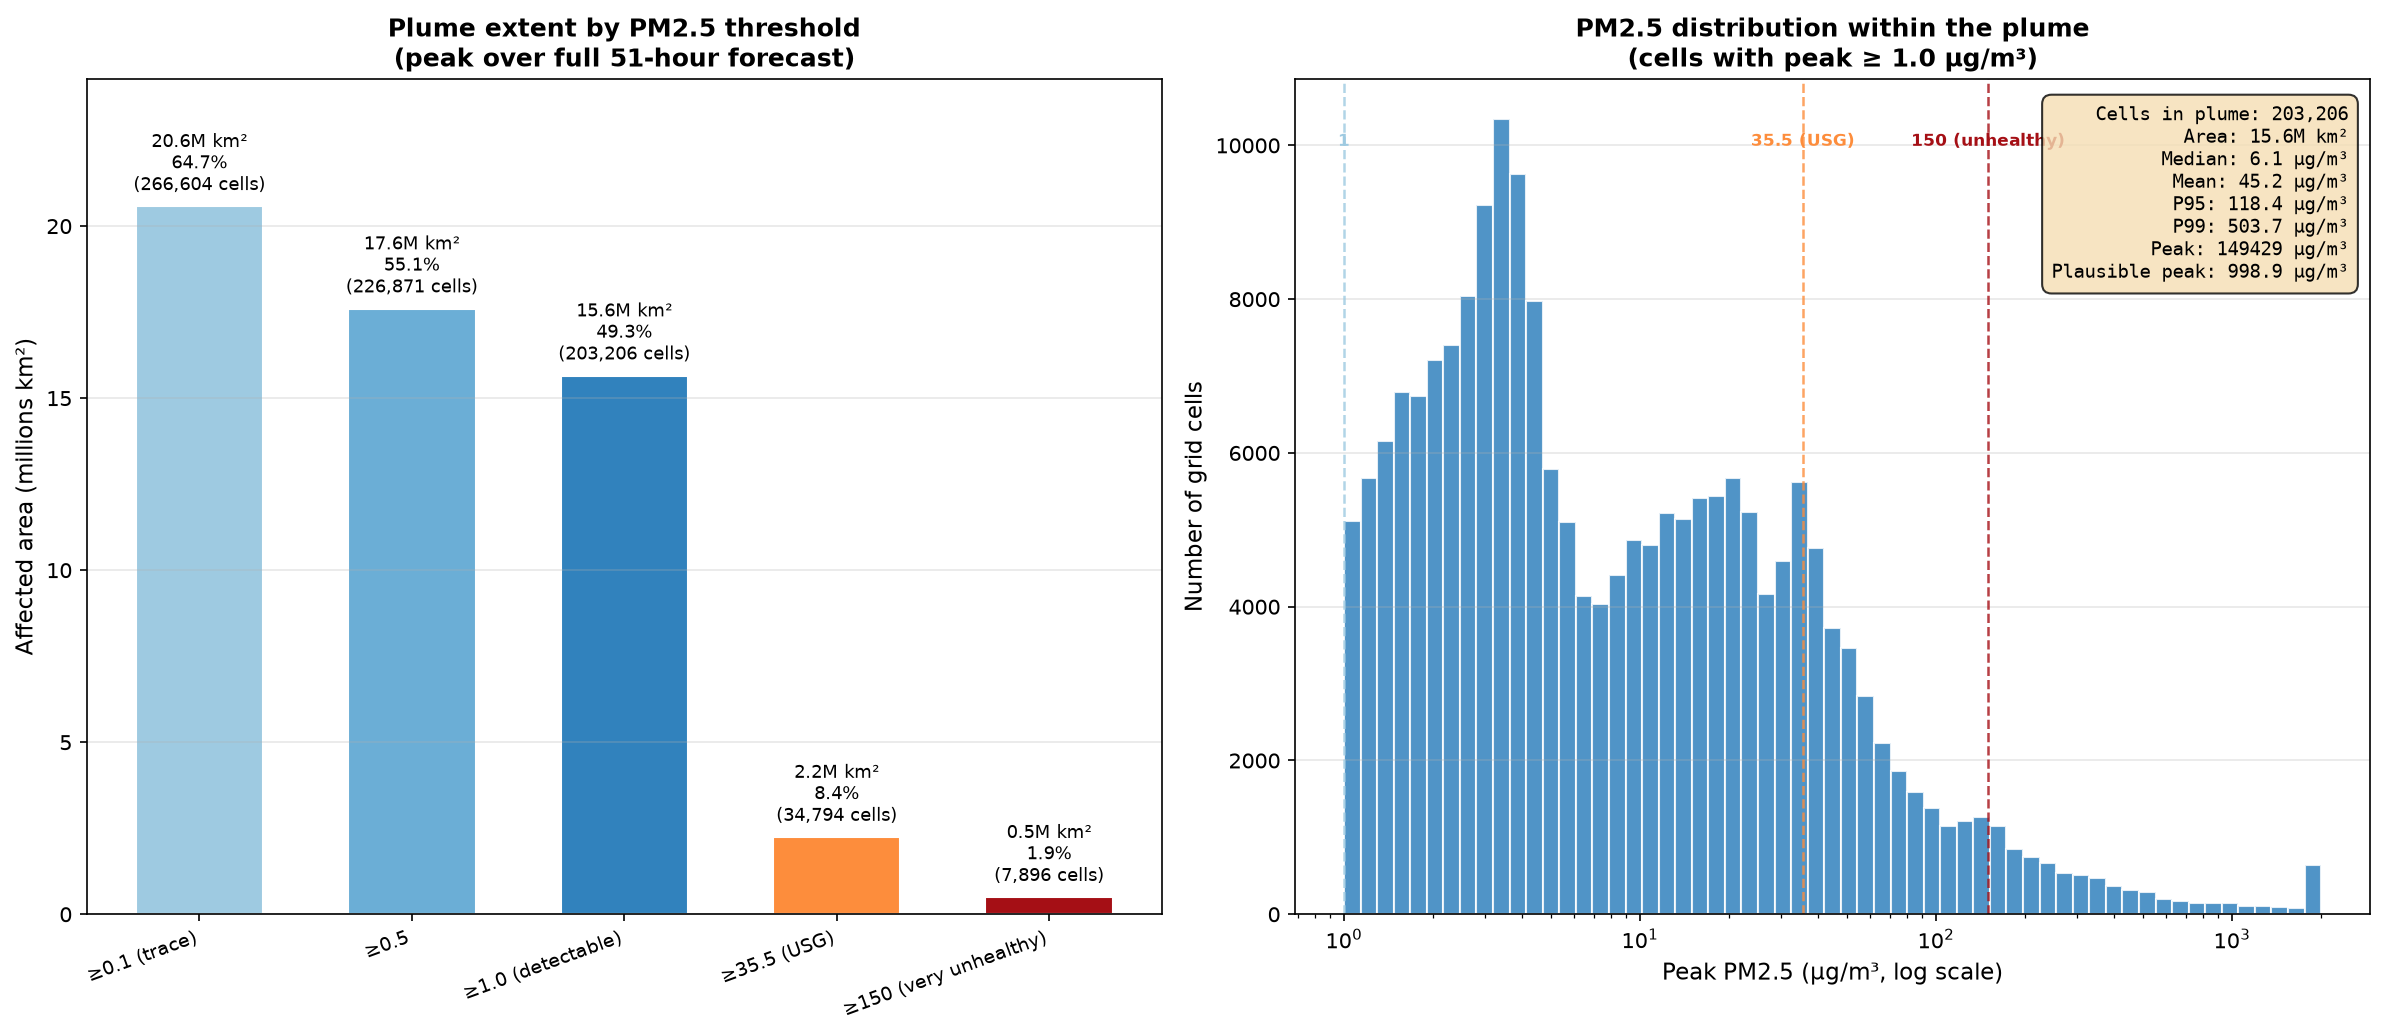

⚠️ **Rolling-URL note** : The firesmoke.ca `/forecasts/current/` file is overwritten each cycle, so dates (July 2026) reflect the current forecast at load time, not the "Sep 26, 2025" date in the NDP record title.

In [11]:
%%ask
Summarize this forecast: what fraction of the grid has any smoke at all, roughly 
how much area is affected in km², and what are the peak and median PM2.5 
concentrations within the plume?